In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as scs
from scipy.io import wavfile
from scipy.signal import find_peaks

plt.close('all')

# Tableau des fréquences de référence (fourni dans l'énoncé)
La = 440
k  = np.arange(-12, 13, 1)
r  = np.power(np.float64(2), np.float64(1.0/12))
f  = La * np.power(r, k)


=== UNE NOTE ===
  Fondamentale : 438.0 Hz
  Note identifiée : 440.00 Hz
  Puissance fondamentale : 0.012387 W


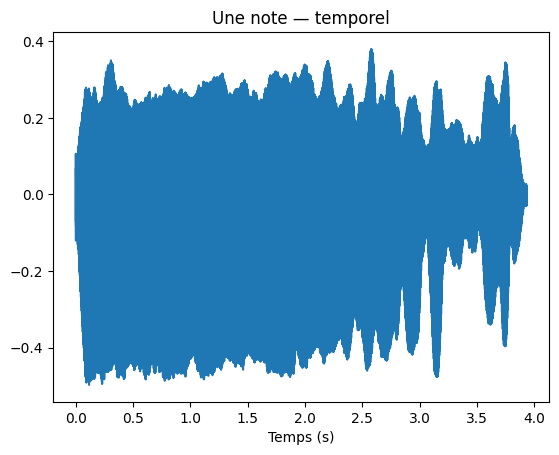

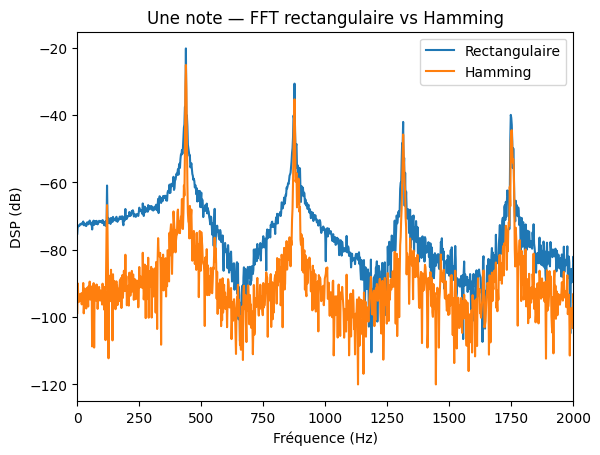

In [ ]:
# =============================================================
# 1. UNE NOTE
# =============================================================
sampFreq, sndinit = wavfile.read('Une_note.wav')
snd = np.float64(sndinit) / (2.**15)
[Nbr, channel] = snd.shape
s1 = snd[:, 0]
N  = s1.size
t  = np.arange(N) / sampFreq

plt.figure()
plt.plot(t, s1)
plt.xlabel('Temps (s)') ; plt.title('Une note — temporel')

# Sélection zone stationnaire (à ajuster visuellement)
N0     = int(0.1 * sampFreq)
N1     = int(0.6 * sampFreq)
s1_win = s1[N0:N1]
N_win  = s1_win.size

# --- FFT (fenêtre rectangulaire implicite) ---
Xf  = np.fft.fft(s1_win)
Fsx = np.arange(N_win) * (sampFreq / N_win)
DSP = (np.abs(Xf)**2 / N_win) * (1 / sampFreq)

plt.figure()
plt.plot(Fsx[:N_win//2], 10*np.log10(np.maximum(DSP[:N_win//2], 1e-12)),
         label='Rectangulaire')

# --- FFT avec fenêtre Hamming ---
win_hamming = np.hamming(N_win)
Xf_h  = np.fft.fft(s1_win * win_hamming)
DSP_h = (np.abs(Xf_h)**2 / N_win) * (1 / sampFreq)
plt.plot(Fsx[:N_win//2], 10*np.log10(np.maximum(DSP_h[:N_win//2], 1e-12)),
         label='Hamming')

plt.xlabel('Fréquence (Hz)') ; plt.ylabel('DSP (dB)')
plt.xlim([0, 2000]) ; plt.legend()
plt.title('Une note — FFT rectangulaire vs Hamming')

# --- Identification de la note ---
idx_max   = np.argmax(DSP_h[:N_win//2])   # on utilise Hamming pour identifier
freq_fond = Fsx[idx_max]
note_idx  = np.argmin(np.abs(f - freq_fond))
print(f"\n=== UNE NOTE ===")
print(f"  Fondamentale : {freq_fond:.1f} Hz")
print(f"  Note identifiée : {f[note_idx]:.2f} Hz")
Px_fond = 2 * (sampFreq / N_win) * DSP_h[idx_max]
print(f"  Puissance fondamentale : {Px_fond:.6f} W")


=== DEUX NOTES ATTÉNUÉES ===
  875.1 Hz -> note réf 880.0 Hz | P = 0.001317 W
  437.5 Hz -> note réf 440.0 Hz | P = 0.013050 W
  Rapport de puissance : 10.0 dB


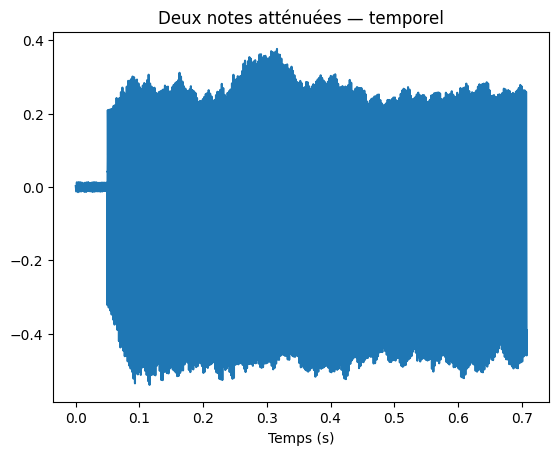

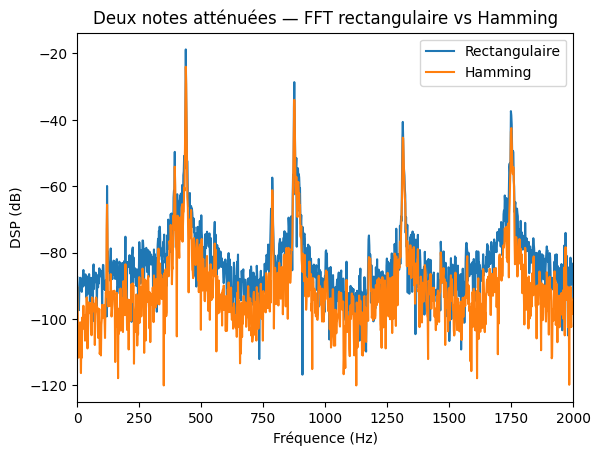

In [ ]:
# =============================================================
# 2. DEUX NOTES ATTÉNUÉES
# =============================================================
sampFreq, sndinit = wavfile.read('Deux_notes_attenuees.wav')
snd = np.float64(sndinit) / (2.**15)
s1  = snd[:, 0]
N   = s1.size
t   = np.arange(N) / sampFreq

plt.figure()
plt.plot(t, s1)
plt.xlabel('Temps (s)') ; plt.title('Deux notes atténuées — temporel')

N0     = int(0.1 * sampFreq) ; N1 = int(0.8 * sampFreq)
s1_win = s1[N0:N1]
N_win  = s1_win.size

# --- FFT rectangulaire ---
Xf  = np.fft.fft(s1_win)
Fsx = np.arange(N_win) * (sampFreq / N_win)
DSP = (np.abs(Xf)**2 / N_win) * (1 / sampFreq)

# --- FFT Hamming ---
win_hamming = np.hamming(N_win)
Xf_h  = np.fft.fft(s1_win * win_hamming)
DSP_h = (np.abs(Xf_h)**2 / N_win) * (1 / sampFreq)

plt.figure()
plt.plot(Fsx[:N_win//2], 10*np.log10(np.maximum(DSP[:N_win//2],  1e-12)),
         label='Rectangulaire')
plt.plot(Fsx[:N_win//2], 10*np.log10(np.maximum(DSP_h[:N_win//2], 1e-12)),
         label='Hamming')
plt.xlabel('Fréquence (Hz)') ; plt.ylabel('DSP (dB)')
plt.xlim([0, 2000]) ; plt.legend()
plt.title('Deux notes atténuées — FFT rectangulaire vs Hamming')

# --- Identification des 2 notes ---
df = sampFreq / N_win
peaks, _ = find_peaks(DSP_h[:N_win//2], height=np.max(DSP_h)*0.01,
                      distance=int(10/df))
top2 = peaks[np.argsort(DSP_h[peaks])[-2:]]
print(f"\n=== DEUX NOTES ATTÉNUÉES ===")
for p in top2:
    note_p = np.argmin(np.abs(f - Fsx[p]))
    Px_p   = 2 * (sampFreq / N_win) * DSP_h[p]
    print(f"  {Fsx[p]:.1f} Hz -> note réf {f[note_p]:.1f} Hz | P = {Px_p:.6f} W")
rapport_dB = 10*np.log10(DSP_h[top2[1]] / DSP_h[top2[0]])
print(f"  Rapport de puissance : {rapport_dB:.1f} dB")


=== DEUX NOTES ATTÉNUÉES ===
  875.1 Hz -> note réf 880.0 Hz | P = 0.001317 W
  437.5 Hz -> note réf 440.0 Hz | P = 0.013050 W
  Rapport de puissance : 10.0 dB


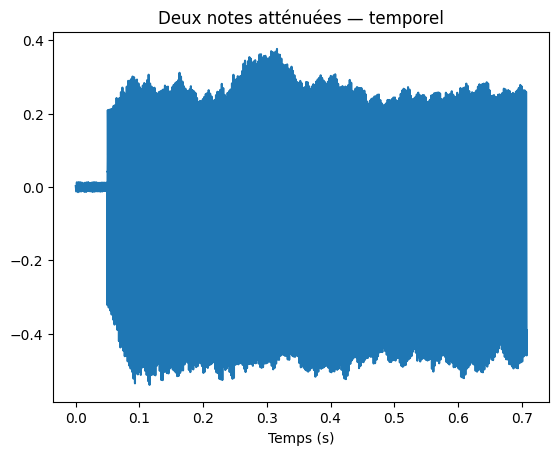

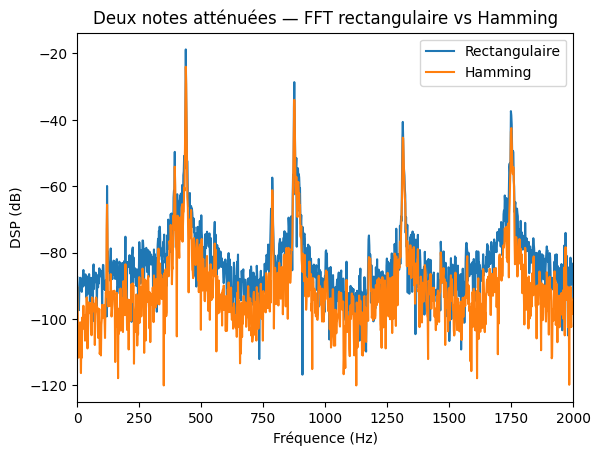

In [ ]:
# =============================================================
# 2. DEUX NOTES ATTÉNUÉES
# =============================================================
sampFreq, sndinit = wavfile.read('Deux_notes_attenuees.wav')
snd = np.float64(sndinit) / (2.**15)
s1  = snd[:, 0]
N   = s1.size
t   = np.arange(N) / sampFreq

plt.figure()
plt.plot(t, s1)
plt.xlabel('Temps (s)') ; plt.title('Deux notes atténuées — temporel')

N0     = int(0.1 * sampFreq) ; N1 = int(0.8 * sampFreq)
s1_win = s1[N0:N1]
N_win  = s1_win.size

# --- FFT rectangulaire ---
Xf  = np.fft.fft(s1_win)
Fsx = np.arange(N_win) * (sampFreq / N_win)
DSP = (np.abs(Xf)**2 / N_win) * (1 / sampFreq)

# --- FFT Hamming ---
win_hamming = np.hamming(N_win)
Xf_h  = np.fft.fft(s1_win * win_hamming)
DSP_h = (np.abs(Xf_h)**2 / N_win) * (1 / sampFreq)

plt.figure()
plt.plot(Fsx[:N_win//2], 10*np.log10(np.maximum(DSP[:N_win//2],  1e-12)),
         label='Rectangulaire')
plt.plot(Fsx[:N_win//2], 10*np.log10(np.maximum(DSP_h[:N_win//2], 1e-12)),
         label='Hamming')
plt.xlabel('Fréquence (Hz)') ; plt.ylabel('DSP (dB)')
plt.xlim([0, 2000]) ; plt.legend()
plt.title('Deux notes atténuées — FFT rectangulaire vs Hamming')

# --- Identification des 2 notes ---
df = sampFreq / N_win
peaks, _ = find_peaks(DSP_h[:N_win//2], height=np.max(DSP_h)*0.01,
                      distance=int(10/df))
top2 = peaks[np.argsort(DSP_h[peaks])[-2:]]
print(f"\n=== DEUX NOTES ATTÉNUÉES ===")
for p in top2:
    note_p = np.argmin(np.abs(f - Fsx[p]))
    Px_p   = 2 * (sampFreq / N_win) * DSP_h[p]
    print(f"  {Fsx[p]:.1f} Hz -> note réf {f[note_p]:.1f} Hz | P = {Px_p:.6f} W")
rapport_dB = 10*np.log10(DSP_h[top2[1]] / DSP_h[top2[0]])
print(f"  Rapport de puissance : {rapport_dB:.1f} dB")


=== DEUX NOTES + BRUIT ===
  876.0 Hz -> note réf 880.0 Hz
  436.0 Hz -> note réf 440.0 Hz


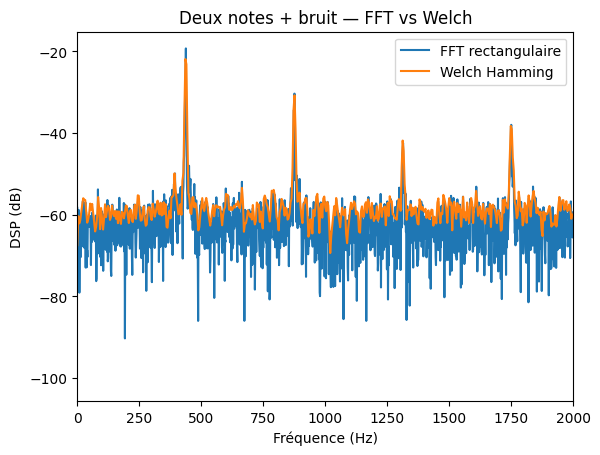

In [ ]:
# =============================================================
# 3. DEUX NOTES + BRUIT BLANC
# =============================================================
sampFreq, sndinit = wavfile.read('Deux_notes_bruit_blanc.wav')
snd = np.float64(sndinit) / (2.**15)
s1  = snd[:, 0]
N   = s1.size

# --- FFT rectangulaire (montre que le bruit noie les raies) ---
Xf  = np.fft.fft(s1)
Fsx = np.arange(N) * (sampFreq / N)
DSP = (np.abs(Xf)**2 / N) * (1 / sampFreq)

plt.figure()
plt.plot(Fsx[:N//2], 10*np.log10(np.maximum(DSP[:N//2], 1e-12)),
         label='FFT rectangulaire')

# --- Welch Hamming (réduit la variance) ---
nperseg  = int(sampFreq / 4)
noverlap = int(nperseg / 2)

Fs_w, Pxx_w = scs.welch(s1, fs=sampFreq, window='hamming',
                          nperseg=nperseg, noverlap=noverlap,
                          return_onesided=True, scaling='density')
plt.plot(Fs_w, 10*np.log10(np.maximum(Pxx_w, 1e-12)), label='Welch Hamming')

plt.xlabel('Fréquence (Hz)') ; plt.ylabel('DSP (dB)')
plt.xlim([0, 2000]) ; plt.legend()
plt.title('Deux notes + bruit — FFT vs Welch')

# --- Identification ---
peaks, _ = find_peaks(Pxx_w, height=np.max(Pxx_w)*0.01, distance=int(10/4))
top2 = peaks[np.argsort(Pxx_w[peaks])[-2:]]
print(f"\n=== DEUX NOTES + BRUIT ===")
for p in top2:
    note_p = np.argmin(np.abs(f - Fs_w[p]))
    print(f"  {Fs_w[p]:.1f} Hz -> note réf {f[note_p]:.1f} Hz")

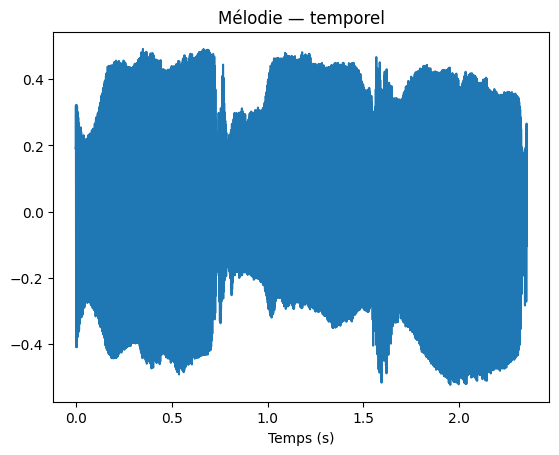

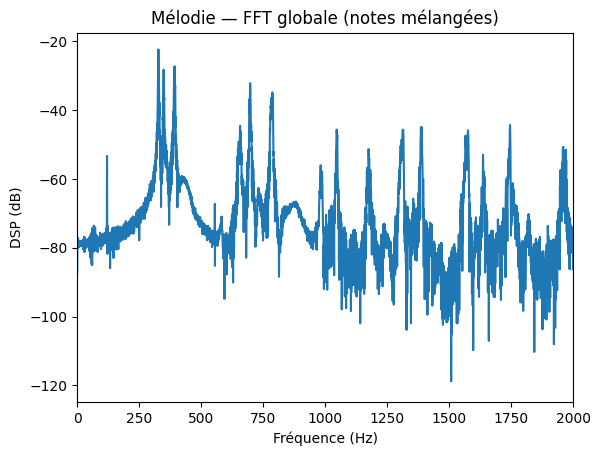

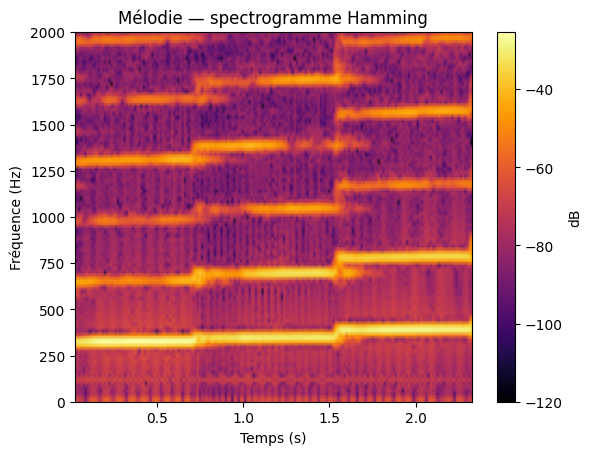

In [ ]:
# =============================================================
# 4. MÉLODIE
# =============================================================
sampFreq, sndinit = wavfile.read('melodie.wav')
snd = np.float64(sndinit) / (2.**15)
s1  = snd[:, 0]
t   = np.arange(s1.size) / sampFreq

plt.figure()
plt.plot(t, s1)
plt.xlabel('Temps (s)') ; plt.title('Mélodie — temporel')

# --- FFT globale (montre que les notes se superposent) ---
Xf  = np.fft.fft(s1)
Fsx = np.arange(s1.size) * (sampFreq / s1.size)
DSP = (np.abs(Xf)**2 / s1.size) * (1 / sampFreq)

plt.figure()
plt.plot(Fsx[:s1.size//2], 10*np.log10(np.maximum(DSP[:s1.size//2], 1e-12)))
plt.xlabel('Fréquence (Hz)') ; plt.ylabel('DSP (dB)')
plt.xlim([0, 2000]) ; plt.title('Mélodie — FFT globale (notes mélangées)')

# --- Spectrogramme avec fenêtre Hamming ---
nperseg_m  = int(sampFreq * 0.05)    # fenêtre 50 ms
noverlap_m = int(nperseg_m * 0.75)   # recouvrement 75%

f_stft, t_stft, Sxx = scs.spectrogram(s1, fs=sampFreq, window='hamming',
                                        nperseg=nperseg_m,
                                        noverlap=noverlap_m,
                                        scaling='density')
plt.figure()
plt.pcolormesh(t_stft, f_stft,
               10*np.log10(np.maximum(Sxx, 1e-12)),
               shading='gouraud', cmap='inferno')
plt.colorbar(label='dB')
plt.ylim([0, 2000])
plt.xlabel('Temps (s)') ; plt.ylabel('Fréquence (Hz)')
plt.title('Mélodie — spectrogramme Hamming')
plt.show()